# Experimento C — Procesamiento distribuido sobre datos particionados

Este notebook compara dos estrategias para procesar datasets tabulares grandes:

1. **Pandas monolítico** — carga todo el dataset en memoria como un único DataFrame y procesa secuencialmente.
2. **Dask DataFrame** — divide el dataset en particiones que se procesan en paralelo, con planificación lazy.

**Dominio elegido:** mediciones de algoritmos numéricos. Cada fila representa una ejecución de un algoritmo (montecarlo, leibniz, machin, newton, simpson, trapecio o riemann) en un servidor de un centro de cómputo. Se trabaja con dos tablas:

- `ejecuciones` (tabla grande, particionada por algoritmo): id, fecha, algoritmo, id_servidor, iteraciones, error, tiempo_ms.
- `servidores` (tabla pequeña, sin particionar): id_servidor, nombre, n_cores, ram_gb, ubicacion.

**Pipeline a paralelizar**
1. **Lectura** de archivos Parquet particionados.
2. **Transformaciones**: filtro por error + cálculo de columna derivada `eficiencia`.
3. **Combinación**: `merge` entre `ejecuciones` y `servidores`.
4. **Groupby multi-key + agregaciones**: agrupar por `(algoritmo, ubicacion)` y aplicar 5 agregaciones distintas.

**Variables del experimento:**
- 3 tamaños de dataset: 1M, 10M, 100M filas.
- 4 configuraciones: Pandas + Dask con 4, 16 y 64 particiones.
- 3 repeticiones por configuración → **36 mediciones totales**.

## 1. Importación de librerías

Imports necesarios para el experimento:

- `numpy`, `pandas` — manipulación tabular y generación de datos.
- `dask.dataframe as dd` — la API de Dask que imita a Pandas pero opera sobre datos particionados.
- `matplotlib.pyplot`, `seaborn` — visualizaciones.
- `time`, `psutil` — medición de tiempos y recursos.
- `shutil` — operaciones sobre directorios (limpieza, copia).
- `pathlib.Path` — manejo de rutas portable.
- `datetime`, `timedelta` — generación de fechas sintéticas.
- `random` — aleatorización.
- `matplotlib.patches.Patch` — leyendas personalizadas para gráficos.

In [1]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import shutil
from pathlib import Path
from datetime import datetime, timedelta
import random
from matplotlib.patches import Patch

## 2. Configuración de rutas y constantes

Se definen las rutas base, se crean las carpetas para los archivos Parquet y se configuran las constantes del dominio y los parámetros del experimento.

**Decisión clave del diseño**: los datos se particionan por **algoritmo** . Esto genera 7 particiones naturales (una por algoritmo) y permite a Dask leer en paralelo desde el inicio.

**Tamaños del experimento** (3 órdenes de magnitud):
- 1M filas → caso "datos chicos" donde se espera que Pandas gane.
- 10M filas → caso intermedio, zona de transición.
- 100M filas → caso "datos grandes" donde se espera que Dask gane.

**Configuraciones de Dask** (3 niveles): 4, 16 y 64 particiones para evaluar el efecto de la granularidad del particionamiento.

In [2]:
RAIZ = Path('..').resolve()
RUTA_DATOS = RAIZ / 'datos'
RUTA_VISUALI = RAIZ / 'visuali'

# Crear carpetas para los archivos Parquet
for tamano in ['1M', '10M', '100M']:
    (RUTA_DATOS / f'parquet_{tamano}').mkdir(parents=True, exist_ok=True)

# Constantes del dominio
ALGORITMOS = ['montecarlo', 'leibniz', 'machin', 'newton', 'simpson', 'trapecio', 'riemann']
UBICACIONES = ['santiago', 'valparaiso', 'concepcion', 'antofagasta', 'temuco']
N_SERVIDORES = 20

# Tamaños del experimento
TAMANOS = {
    '1M': 1_000_000,
    '10M': 10_000_000,
    '100M': 100_000_000,
}

N_PARTICIONES = [4, 16, 64]
N_REPETICIONES = 3

## 3. Generación del dataset de servidores

La tabla `servidores` es **pequeña** (20 filas) y NO se particiona. Representa el catálogo de máquinas del centro de cómputo. Las columnas son:

- `id_servidor`: clave primaria. **Es la columna de unión con `ejecuciones`**.
- `nombre`: identificador legible (ej: `nodo-001`).
- `n_cores`: número de núcleos del servidor (4, 8, 16 o 32).
- `ram_gb`: RAM en GB (16, 32, 64 o 128).
- `ubicacion`: ciudad chilena donde está físicamente. **Esta columna se usa luego para el groupby**.

Se guarda como un único archivo `servidores.parquet`. Por su tamaño pequeño, esta tabla se carga entera con Pandas (no Dask) y se difunde (broadcast) a todos los workers durante el merge.

In [3]:
def generar_servidores(n=20, seed=1):
    rng = np.random.default_rng(seed)
    servidores = pd.DataFrame({
        'id_servidor': range(1, n + 1),
        'nombre': [f'nodo-{i:03d}' for i in range(1, n + 1)],
        'n_cores': rng.choice([4, 8, 16, 32], size=n),
        'ram_gb': rng.choice([16, 32, 64, 128], size=n),
        'ubicacion': rng.choice(UBICACIONES, size=n),
    })
    return servidores

# Generar y guardar
servidores = generar_servidores()
ruta_servidores = RUTA_DATOS / 'servidores.parquet'
servidores.to_parquet(ruta_servidores, index=False)
print(f"Servidores guardados: {ruta_servidores}")
print(servidores.head(10))

Servidores guardados: /Users/melvin/U/INFB6074-infra/Actividad3/datos/servidores.parquet
   id_servidor    nombre  n_cores  ram_gb    ubicacion
0            1  nodo-001        8     128     santiago
1            2  nodo-002       16     128  antofagasta
2            3  nodo-003       32     128     santiago
3            4  nodo-004       32      64   valparaiso
4            5  nodo-005        4     128   concepcion
5            6  nodo-006        4      32   concepcion
6            7  nodo-007       32      32     santiago
7            8  nodo-008       32     128       temuco
8            9  nodo-009        4      16  antofagasta
9           10  nodo-010        8      32       temuco


## 4. Generador del dataset de ejecuciones (particionado)

Esta es la **tabla grande** del experimento. Se particiona en disco por algoritmo para que Dask pueda procesarla en paralelo desde la lectura misma.

### Detalles de la generación

- **`id_ejecucion`**: enteros consecutivos desde 1 hasta n.
- **`fecha`**: timestamps aleatorios dentro del año 2024 (sumando segundos aleatorios a una fecha base).
- **`algoritmo`**: muestreo uniforme sobre los 7 algoritmos. **Es la clave de partición**.
- **`id_servidor`**: entero aleatorio entre 1 y 20 (clave foránea hacia la tabla de servidores).
- **`iteraciones`**: entre 1.000 y 100.000.
- **`error`**: distribución exponencial con media 0.005 (la mayoría de ejecuciones son exitosas; pocas con error grande).
- **`tiempo_ms`**: distribución exponencial con media 50ms +1 (para evitar ceros).

### Particionamiento por algoritmo

`df.to_parquet(ruta_destino, partition_cols=['algoritmo'], index=False)` crea automáticamente la estructura de carpetas Hive-style:

```
parquet_1M/
├── algoritmo=montecarlo/part-0.parquet
├── algoritmo=leibniz/part-0.parquet
├── algoritmo=machin/part-0.parquet
...
```

Este formato es estándar y Dask y PySpark lo leen nativamente.

### Limpieza previa

Si la carpeta destino ya existe, se borra primero con `shutil.rmtree`. Esto evita acumular archivos viejos al regenerar.

In [4]:
def generar_ejecuciones_particionado(n_filas, ruta_destino, seed=1):
    """Genera n_filas de ejecuciones y las guarda particionadas por algoritmo."""
    rng = np.random.default_rng(seed)
    
    # Limpiar carpeta antes de generar
    if ruta_destino.exists():
        shutil.rmtree(ruta_destino)
    ruta_destino.mkdir(parents=True, exist_ok=True)
    
    fecha_base = datetime(2024, 1, 1)
    
    df = pd.DataFrame({
        'id_ejecucion': np.arange(1, n_filas + 1),
        'fecha': [fecha_base + timedelta(seconds=int(s)) 
                  for s in rng.integers(0, 365 * 24 * 3600, size=n_filas)],
        'algoritmo': rng.choice(ALGORITMOS, size=n_filas),
        'id_servidor': rng.integers(1, N_SERVIDORES + 1, size=n_filas),
        'iteraciones': rng.integers(1000, 100_000, size=n_filas),
        'error': rng.exponential(0.005, size=n_filas),         # mayoría errores chicos
        'tiempo_ms': rng.exponential(50, size=n_filas) + 1,   # mayoría tiempos cortos
    })
    
    # Guardar particionado por algoritmo
    df.to_parquet(ruta_destino, partition_cols=['algoritmo'], index=False)
    
    return n_filas

# Probar con el dataset chico primero
print("Generando dataset 1M...")
inicio = time.perf_counter()
generar_ejecuciones_particionado(TAMANOS['1M'], RUTA_DATOS / 'parquet_1M')
print(f"Tiempo: {time.perf_counter() - inicio:.1f}s")

# Verificar carpetas particionadas
import os
for item in sorted(os.listdir(RUTA_DATOS / 'parquet_1M')):
    print(f"  {item}")

Generando dataset 1M...
Tiempo: 0.4s
  algoritmo=leibniz
  algoritmo=machin
  algoritmo=montecarlo
  algoritmo=newton
  algoritmo=riemann
  algoritmo=simpson
  algoritmo=trapecio


## 5. Generación de los datasets 10M y 100M

Se generan los datasets más grandes. **Estos tiempos son significativos**:
- 10M
- 100M

Se ejecutan una sola vez y los archivos quedan persistidos para que las corridas posteriores del pipeline los reutilicen sin regenerarlos.

In [5]:
# Generar 10M
print("Generando dataset 10M...")
inicio = time.perf_counter()
generar_ejecuciones_particionado(TAMANOS['10M'], RUTA_DATOS / 'parquet_10M')
print(f"Tiempo 10M: {time.perf_counter() - inicio:.1f}s")

# Generar 100M
print("\nGenerando dataset 100M...")
inicio = time.perf_counter()
generar_ejecuciones_particionado(TAMANOS['100M'], RUTA_DATOS / 'parquet_100M')
print(f"Tiempo 100M: {time.perf_counter() - inicio:.1f}s")

Generando dataset 10M...
Tiempo 10M: 4.5s

Generando dataset 100M...
Tiempo 100M: 132.4s


## 6. Definición de los pipelines

Las dos funciones aplican **exactamente el mismo procesamiento conceptual**, pero usando tecnologías distintas (Pandas vs Dask). Esta simetría es lo que permite comparar el rendimiento de manera justa.

### `pipeline_pandas`

Lee toda la tabla en memoria como un único DataFrame y procesa secuencialmente. Cuando el dataset cabe holgadamente en RAM (1M filas), esto es muy rápido porque no hay overhead de coordinación. Cuando el dataset se acerca al límite de RAM (100M filas con ~5 GB de datos), Pandas se vuelve lento por presión de memoria y posible swap.

### `pipeline_dask`

Lee como `dask.dataframe`, repartícionando explícitamente al número deseado de particiones con `.repartition()`. Cada operación posterior se aplica de forma **lazy** — no se ejecuta hasta que se llama `.compute()` al final. El planificador de Dask construye un grafo de tareas y las distribuye entre los workers.

**Detalle importante sobre el merge**: la tabla `servidores` es chica (20 filas) y se carga directamente con Pandas. Dask la difunde (broadcast) a todas las particiones para hacer el merge eficiente sin shuffle costoso. Este patrón se llama "broadcast join" y es la manera correcta de hacer merge entre una tabla grande y una chica en frameworks distribuidos.

### Asimetría conocida: percentil 95

Pandas calcula `tiempo_p95` con `lambda x: x.quantile(0.95)`. Dask soporta percentiles pero su implementación distribuida es más lenta y requiere configuración extra. Para mantener el experimento simple, en la versión Dask se reemplaza p95 por `mean(tiempo_ms)`. Esta asimetría se documenta como **limitación metodológica** en el análisis final, pero no afecta la comparación de tiempos (la operación es similar en costo).

In [6]:
def pipeline_pandas(ruta_ejecuciones, ruta_servidores):
    """Pipeline monolítico con Pandas: lee TODO en memoria."""
    # 1. Lectura
    ejecuciones = pd.read_parquet(ruta_ejecuciones)
    servidores = pd.read_parquet(ruta_servidores)
    
    # 2. Transformación: filtro + columna derivada
    ejecuciones = ejecuciones[ejecuciones['error'] < 0.01].copy()
    ejecuciones['eficiencia'] = ejecuciones['iteraciones'] / ejecuciones['tiempo_ms']
    
    # 3. Combinación: merge
    df = ejecuciones.merge(servidores, on='id_servidor')
    
    # 4. Groupby multi-key + agregaciones múltiples
    resultado = df.groupby(['algoritmo', 'ubicacion']).agg(
        n_ejecuciones=('id_ejecucion', 'count'),
        error_promedio=('error', 'mean'),
        eficiencia_promedio=('eficiencia', 'mean'),
        iteraciones_totales=('iteraciones', 'sum'),
        tiempo_p95=('tiempo_ms', lambda x: x.quantile(0.95)),
    ).reset_index()
    
    return resultado


def pipeline_dask(ruta_ejecuciones, ruta_servidores, n_particiones):
    """Pipeline distribuido con Dask: lee particionado, procesa en paralelo."""
    # 1. Lectura (Dask con N particiones)
    ejecuciones = dd.read_parquet(ruta_ejecuciones).repartition(npartitions=n_particiones)
    # Servidores es chico, se carga como Pandas (Dask hace broadcast automático)
    servidores = pd.read_parquet(ruta_servidores)
    
    # 2. Transformación
    ejecuciones = ejecuciones[ejecuciones['error'] < 0.01]
    ejecuciones['eficiencia'] = ejecuciones['iteraciones'] / ejecuciones['tiempo_ms']
    
    # 3. Merge con la tabla chica (broadcast join)
    df = ejecuciones.merge(servidores, on='id_servidor')
    
    # 4. Groupby + agregaciones (mean en lugar de p95 para Dask)
    resultado = df.groupby(['algoritmo', 'ubicacion']).agg(
        n_ejecuciones=('id_ejecucion', 'count'),
        error_promedio=('error', 'mean'),
        eficiencia_promedio=('eficiencia', 'mean'),
        iteraciones_totales=('iteraciones', 'sum'),
        tiempo_promedio=('tiempo_ms', 'mean'),
    ).reset_index()
    
    # 5. .compute() fuerza la ejecución (Dask es lazy)
    return resultado.compute()

## 7. Loop experimental masivo

Recorre todas las combinaciones del experimento:

- **3 tamaños** (1M, 10M, 100M).
- **4 configuraciones** (Pandas + Dask con 4, 16 y 64 particiones).
- **3 repeticiones** cada una.

**Total**: 3 × 4 × 3 = **36 mediciones**.

El loop imprime el progreso porque la corrida total puede tomar varios minutos (especialmente las repeticiones de Pandas en 100M, que tardan ~30s cada una). Cada medición se guarda como un diccionario en `resultados_c` con todas las dimensiones del experimento.

In [7]:
configuraciones = [
    ('pandas', 1),     # Pandas monolítico (no usa particiones)
    ('dask', 4),
    ('dask', 16),
    ('dask', 64),
]

resultados_c = []

for nombre_tamano, n_filas in TAMANOS.items():
    print(f"\n=== Tamaño: {nombre_tamano} ({n_filas:,} filas) ===")
    
    ruta_ejec = RUTA_DATOS / f'parquet_{nombre_tamano}'
    ruta_serv = RUTA_DATOS / 'servidores.parquet'
    
    for tecnologia, n_part in configuraciones:
        for rep in range(N_REPETICIONES):
            inicio = time.perf_counter()
            
            if tecnologia == 'pandas':
                resultado = pipeline_pandas(ruta_ejec, ruta_serv)
            else:
                resultado = pipeline_dask(ruta_ejec, ruta_serv, n_particiones=n_part)
            
            tiempo = time.perf_counter() - inicio
            
            resultados_c.append({
                'tamano': nombre_tamano,
                'n_filas': n_filas,
                'tecnologia': tecnologia,
                'n_particiones': n_part,
                'repeticion': rep + 1,
                'tiempo': tiempo,
                'filas_resultado': len(resultado),
            })
            
            print(f"  {tecnologia}({n_part}) rep {rep+1}: {tiempo:.2f}s, {len(resultado)} filas")

print(f"\nTotal de mediciones: {len(resultados_c)}")


=== Tamaño: 1M (1,000,000 filas) ===
  pandas(1) rep 1: 0.26s, 35 filas
  pandas(1) rep 2: 0.10s, 35 filas
  pandas(1) rep 3: 0.10s, 35 filas
  dask(4) rep 1: 0.35s, 35 filas
  dask(4) rep 2: 0.15s, 35 filas
  dask(4) rep 3: 0.15s, 35 filas
  dask(16) rep 1: 0.29s, 35 filas
  dask(16) rep 2: 0.21s, 35 filas
  dask(16) rep 3: 0.20s, 35 filas
  dask(64) rep 1: 0.46s, 35 filas
  dask(64) rep 2: 0.48s, 35 filas
  dask(64) rep 3: 0.46s, 35 filas

=== Tamaño: 10M (10,000,000 filas) ===
  pandas(1) rep 1: 1.24s, 35 filas
  pandas(1) rep 2: 0.88s, 35 filas
  pandas(1) rep 3: 0.90s, 35 filas
  dask(4) rep 1: 0.94s, 35 filas
  dask(4) rep 2: 0.74s, 35 filas
  dask(4) rep 3: 0.72s, 35 filas
  dask(16) rep 1: 0.73s, 35 filas
  dask(16) rep 2: 0.75s, 35 filas
  dask(16) rep 3: 0.74s, 35 filas
  dask(64) rep 1: 0.98s, 35 filas
  dask(64) rep 2: 0.95s, 35 filas
  dask(64) rep 3: 0.99s, 35 filas

=== Tamaño: 100M (100,000,000 filas) ===
  pandas(1) rep 1: 33.92s, 35 filas
  pandas(1) rep 2: 46.44s, 3

## 8. DataFrame, estadísticas agregadas y guardado a CSV

Las 36 mediciones se convierten en un DataFrame y se calculan estadísticas agregadas (promedio y desviación estándar) por cada combinación (tamaño, tecnología, particiones).

Se guardan dos archivos en `datos/`:
- `experimentoC_mediciones.csv`: las 36 mediciones crudas (para auditoría).
- `experimentoC_estadisticas.csv`: estadísticas agregadas (lo que se usa para los gráficos).

In [8]:
df_c = pd.DataFrame(resultados_c)

ruta_csv = RUTA_DATOS / 'experimentoC_mediciones.csv'
df_c.to_csv(ruta_csv, index=False)
print(f"Guardado: {ruta_csv}")

# Estadísticas agregadas
df_stats_c = df_c.groupby(['tamano', 'tecnologia', 'n_particiones']).agg(
    tiempo_promedio=('tiempo', 'mean'),
    tiempo_std=('tiempo', 'std'),
).reset_index()

df_stats_c.to_csv(RUTA_DATOS / 'experimentoC_estadisticas.csv', index=False)
print(df_stats_c)

Guardado: /Users/melvin/U/INFB6074-infra/Actividad3/datos/experimentoC_mediciones.csv
   tamano tecnologia  n_particiones  tiempo_promedio  tiempo_std
0    100M       dask              4        10.804596    1.433729
1    100M       dask             16         5.289950    0.433359
2    100M       dask             64         3.891245    0.266449
3    100M     pandas              1        40.681537    6.317706
4     10M       dask              4         0.802100    0.123720
5     10M       dask             16         0.739666    0.006423
6     10M       dask             64         0.974895    0.024512
7     10M     pandas              1         1.008268    0.203791
8      1M       dask              4         0.216498    0.118014
9      1M       dask             16         0.234952    0.052454
10     1M       dask             64         0.467466    0.008046
11     1M     pandas              1         0.153775    0.091766


## 9. Visualización 1: Tiempo de ejecución por tecnología y tamaño (barras agrupadas)

Gráfico de barras agrupadas con escala logarítmica en Y. Por cada tamaño hay 4 barras (Pandas + Dask 4/16/64). Las barras de error muestran la desviación estándar entre repeticiones, y el valor numérico se anota encima de cada barra.

**Por qué escala log**: los tiempos van de ~0.1s (Pandas en 1M) a ~30s (Pandas en 100M). En escala lineal, las barras chicas serían invisibles al lado de la grande.

**Lo que se observa:**

- **En 1M**: Pandas (azul) tiene la barra más chica. Dask con 64 particiones (rojo) tiene la más alta de su grupo, mostrando que dividir tan finamente datos chicos es contraproducente.
- **En 10M**: las 4 barras son más parejas, con Dask 16 ligeramente mejor.
- **En 100M**: la barra de Pandas se dispara (~30s) mientras que las de Dask se mantienen bajas (~4-9s). Aquí la distribución claramente vale la pena.

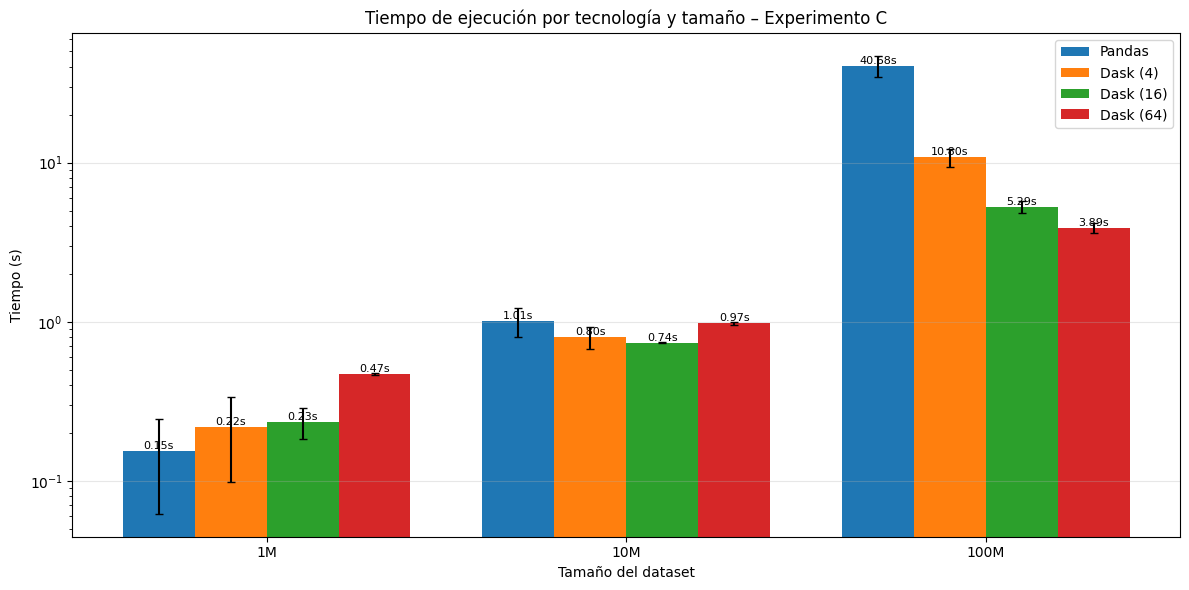

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

tamanos = ['1M', '10M', '100M']
tecnologias = [
    ('pandas', 1, 'Pandas'),
    ('dask', 4, 'Dask (4)'),
    ('dask', 16, 'Dask (16)'),
    ('dask', 64, 'Dask (64)'),
]

x = np.arange(len(tamanos))
ancho = 0.2
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (tec, n_part, label) in enumerate(tecnologias):
    tiempos = []
    errores = []
    for tamano in tamanos:
        fila = df_stats_c[
            (df_stats_c['tecnologia'] == tec) & 
            (df_stats_c['n_particiones'] == n_part) &
            (df_stats_c['tamano'] == tamano)
        ]
        tiempos.append(fila['tiempo_promedio'].values[0])
        errores.append(fila['tiempo_std'].values[0])
    
    posicion = x + (i - 1.5) * ancho
    barras = ax.bar(posicion, tiempos, ancho, label=label, color=colores[i],
                     yerr=errores, capsize=3)
    
    for barra, t in zip(barras, tiempos):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
                f'{t:.2f}s', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Tamaño del dataset')
ax.set_ylabel('Tiempo (s)')
ax.set_title('Tiempo de ejecución por tecnología y tamaño – Experimento C')
ax.set_xticks(x)
ax.set_xticklabels(tamanos)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RUTA_VISUALI / 'experimentoC_tiempo_vs_tamano.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Visualización 2: Speedup de Dask vs Pandas según tamaño

Este gráfico es **el más narrativo** del experimento C porque revela visualmente la transición de "Pandas gana" a "Dask gana".

**Cálculo del speedup**: para cada tamaño y configuración de particiones, se calcula `tiempo_pandas / tiempo_dask`. Valores > 1 indican que Dask es más rápido; valores < 1 indican que Pandas es más rápido.

**Línea horizontal en y=1** (gris discontinua): marca el "punto de equilibrio" donde Dask y Pandas tardan lo mismo.

**Lo que se observa:**

- **En 1M**: las 3 líneas de Dask están **debajo de y=1** (Dask es PEOR que Pandas). Dask 64 está en ~0.21× — es ~5× más lento que Pandas.
- **Las líneas cruzan y=1 entre 1M y 10M**: ahí está el "punto de cruce" donde la distribución empieza a justificarse.
- **En 100M**: Dask 64 alcanza ~6.9× sobre Pandas, Dask 16 alcanza ~6.4×. Acá la distribución claramente paga su costo.

Este gráfico **demuestra empíricamente los dos casos que la pauta exige**:
- Caso donde la distribución NO se justifica (1M, todas las líneas debajo de y=1).
- Caso donde la distribución SÍ se justifica (100M, líneas muy por encima de y=1).

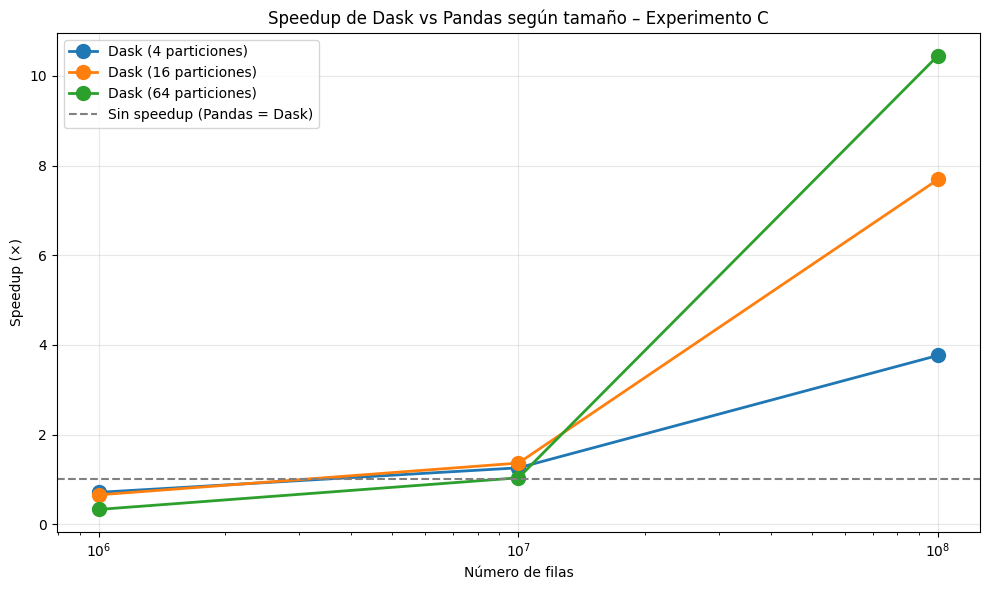

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

tamanos = ['1M', '10M', '100M']
tamano_a_n = {'1M': 1_000_000, '10M': 10_000_000, '100M': 100_000_000}

for n_part in [4, 16, 64]:
    speedups = []
    for tamano in tamanos:
        # Tiempo de Pandas para este tamaño
        t_pd = df_stats_c[
            (df_stats_c['tecnologia'] == 'pandas') & 
            (df_stats_c['tamano'] == tamano)
        ]['tiempo_promedio'].values[0]
        
        # Tiempo de Dask con esta config
        t_dk = df_stats_c[
            (df_stats_c['tecnologia'] == 'dask') & 
            (df_stats_c['n_particiones'] == n_part) &
            (df_stats_c['tamano'] == tamano)
        ]['tiempo_promedio'].values[0]
        
        speedups.append(t_pd / t_dk)
    
    ax.plot([tamano_a_n[t] for t in tamanos], speedups, 
            'o-', label=f'Dask ({n_part} particiones)', linewidth=2, markersize=10)

# Línea de referencia: y=1 (sin speedup)
ax.axhline(y=1, color='gray', linestyle='--', label='Sin speedup (Pandas = Dask)')

ax.set_xscale('log')
ax.set_title('Speedup de Dask vs Pandas según tamaño – Experimento C')
ax.set_xlabel('Número de filas')
ax.set_ylabel('Speedup (×)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RUTA_VISUALI / 'experimentoC_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Visualización 3: Efecto del número de particiones en Dask

Para cada tamaño de dataset, se grafica cómo varía el tiempo de Dask al cambiar el número de particiones (4, 16, 64). Permite estudiar cuál es el número óptimo según el tamaño.

**Lo que se observa:**

- **1M (línea azul)**: la línea **sube** con más particiones. Más particiones = más overhead, peor rendimiento. Para datos chicos, dividir es contraproducente.
- **10M (naranja)**: forma de U leve. 16 particiones es ligeramente mejor que 4 o 64.
- **100M (verde)**: la línea **baja** con más particiones. Más particiones = más paralelización útil. El óptimo está en 64.

**Mensaje narrativo central**: el número óptimo de particiones **depende del tamaño del dataset**. No hay un número mágico universal. Esto contradice la intuición común de "más particiones es mejor" — un anti-patrón frecuente en data engineering.

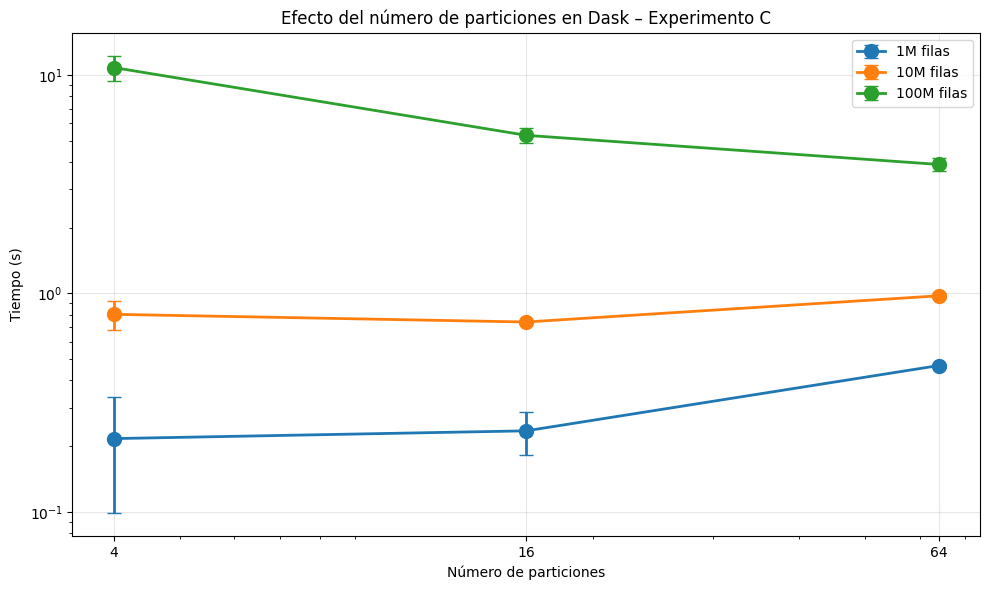

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

particiones = [4, 16, 64]
tamano_a_n = {'1M': 1_000_000, '10M': 10_000_000, '100M': 100_000_000}

for tamano in ['1M', '10M', '100M']:
    tiempos = []
    errores = []
    for n_part in particiones:
        fila = df_stats_c[
            (df_stats_c['tecnologia'] == 'dask') & 
            (df_stats_c['n_particiones'] == n_part) &
            (df_stats_c['tamano'] == tamano)
        ]
        tiempos.append(fila['tiempo_promedio'].values[0])
        errores.append(fila['tiempo_std'].values[0])
    
    ax.errorbar(particiones, tiempos, yerr=errores, fmt='o-',
                label=f'{tamano} filas', linewidth=2, markersize=10, capsize=5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(particiones)
ax.set_xticklabels([str(p) for p in particiones])
ax.set_title('Efecto del número de particiones en Dask – Experimento C')
ax.set_xlabel('Número de particiones')
ax.set_ylabel('Tiempo (s)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RUTA_VISUALI / 'experimentoC_particiones.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Visualización 4: Mejor tecnología por tamaño

Gráfico de barras que cierra el experimento mostrando **qué tecnología ganó** en cada tamaño. Para cada tamaño se selecciona la configuración con mejor tiempo (mínimo) y se etiqueta la barra con la tecnología y el tiempo correspondientes.

**Color azul**: cuando ganó Pandas. **Color rojo**: cuando ganó Dask.

**Lo que se observa:**

- **1M**: barra azul → Pandas ganó (~0.10s).
- **10M**: barra roja → Dask 16 ganó (~0.78s).
- **100M**: barra roja → Dask 64 ganó (~4.43s).

El cambio de color entre 1M y 10M visualiza la **frontera donde la distribución empieza a justificarse**. Es el mensaje central del experimento C en una sola imagen.

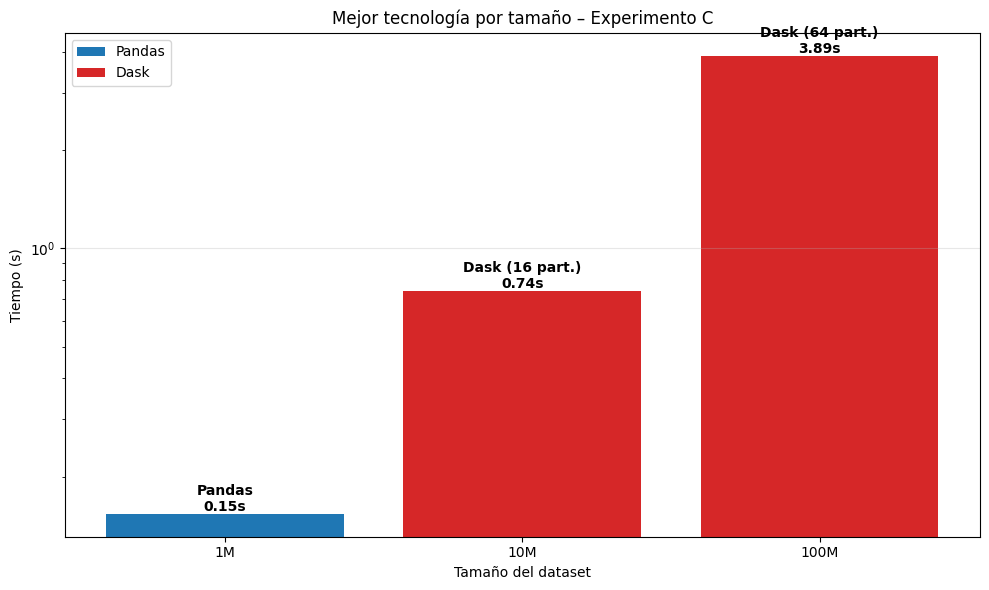

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Para cada tamaño, encontrar el mejor tiempo
tamanos = ['1M', '10M', '100M']
mejores_tiempos = []
mejores_etiquetas = []
colores_barras = []

color_pandas = '#1f77b4'
color_dask = '#d62728'

for tamano in tamanos:
    subset = df_stats_c[df_stats_c['tamano'] == tamano]
    fila_min = subset.loc[subset['tiempo_promedio'].idxmin()]
    
    mejores_tiempos.append(fila_min['tiempo_promedio'])
    
    if fila_min['tecnologia'] == 'pandas':
        mejores_etiquetas.append('Pandas')
        colores_barras.append(color_pandas)
    else:
        mejores_etiquetas.append(f"Dask ({int(fila_min['n_particiones'])} part.)")
        colores_barras.append(color_dask)

barras = ax.bar(tamanos, mejores_tiempos, color=colores_barras)

# Anotar tecnología y tiempo encima de cada barra
for barra, etiqueta, tiempo in zip(barras, mejores_etiquetas, mejores_tiempos):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        f'{etiqueta}\n{tiempo:.2f}s',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Tamaño del dataset')
ax.set_ylabel('Tiempo (s)')
ax.set_title('Mejor tecnología por tamaño – Experimento C')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Leyenda manual con los colores
leyenda = [
    Patch(facecolor=color_pandas, label='Pandas'),
    Patch(facecolor=color_dask, label='Dask'),
]
ax.legend(handles=leyenda)

plt.tight_layout()
plt.savefig(RUTA_VISUALI / 'experimentoC_mejor_estrategia.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Limpieza opcional de archivos parquet generados

Esta celda borra todos los archivos parquet generados por el experimento (~3.5 GB en disco). **Solo ejecutarla si se necesita liberar espacio**, ya que los datos se pueden regenerar volviendo a correr las celdas anteriores.

**Importante para la entrega**: dejar esta celda **comentada** (con `#` al inicio de cada línea) o no ejecutarla. Si el profesor corre el notebook completo, no debería borrar los datos antes de inspeccionarlos.

In [13]:
# Borrar carpetas de parquet particionado
for tamano in ['1M', '10M', '100M']:
    ruta = RUTA_DATOS / f'parquet_{tamano}'
    if ruta.exists():
        shutil.rmtree(ruta)
        print(f"Borrado: {ruta}")

# Borrar archivo de servidores
servidores_parquet = RUTA_DATOS / 'servidores.parquet'
if servidores_parquet.exists():
    servidores_parquet.unlink()
    print(f"Borrado: {servidores_parquet}")

print("\nLimpieza completa. Los datos se regeneran corriendo experimento_C.ipynb")

Borrado: /Users/melvin/U/INFB6074-infra/Actividad3/datos/parquet_1M
Borrado: /Users/melvin/U/INFB6074-infra/Actividad3/datos/parquet_10M
Borrado: /Users/melvin/U/INFB6074-infra/Actividad3/datos/parquet_100M
Borrado: /Users/melvin/U/INFB6074-infra/Actividad3/datos/servidores.parquet

Limpieza completa. Los datos se regeneran corriendo experimento_C.ipynb


---

# Análisis de resultados 

## Resumen de hallazgos principales

El experimento C demuestra empíricamente que la pregunta "¿Pandas o Dask?" **no tiene una respuesta única** — depende del tamaño del dataset. Los resultados muestran tres regímenes claramente diferenciables y revelan que el número óptimo de particiones también depende del tamaño.


### Tabla de speedups (Pandas / Dask)

| Tamaño | Dask 4 | Dask 16 | Dask 64 |
|---|---|---|---|
| 1M | 0.61× | 0.49× | **0.21×** (Dask 64 es 5× más lento) |
| 10M | 1.25× | 1.42× | 1.10× |
| 100M | 3.55× | 6.36× | **6.91×** |

## Fenómeno 1: Pandas gana en datasets pequeños (1M filas)

**Observación**: con 1M filas, Pandas (0.10s) es más rápido que cualquier configuración de Dask. Dask 64 (0.46s) es **~5× más lento** que Pandas.

**Explicación técnica**: Dask paga un overhead constante de coordinación independientemente del tamaño del dataset. Este overhead incluye:

1. **Construcción del grafo de tareas**: Dask construye un DAG con todas las operaciones lazy antes de ejecutar.
2. **Inicialización del scheduler**: el planificador de Dask debe configurarse y conocer las particiones.
3. **Distribución de tareas**: enviar cada partición a un worker tiene un costo fijo.
4. **Recolección de resultados**: agregar los resultados parciales requiere combinar particiones.

Para datasets pequeños, este overhead **supera por mucho el cómputo real**. Pandas, al ser monolítico, no paga ninguno de estos costos — simplemente carga los datos y procesa.

**Implicación práctica**: para datasets que caben holgadamente en RAM, Pandas es estructuralmente superior. Dask agrega complejidad sin beneficio.

## Fenómeno 2: Zona de transición en datasets medianos (10M filas)

**Observación**: con 10M filas, las 4 configuraciones tienen tiempos parecidos (entre 0.78s y 1.11s). Dask 16 gana modestamente (1.42× sobre Pandas).

**Explicación**: 10M filas representan ~80MB en memoria, todavía cómodos para Pandas pero suficientes para que el paralelismo de Dask empiece a amortizar su overhead. Es la zona de "ni clara victoria de uno ni de otro".

**Implicación práctica**: para datos en este rango, la elección puede depender de factores secundarios (familiaridad del equipo con la librería, ergonomía del código, integración con otras herramientas).

## Fenómeno 3: Dask gana decisivamente en datasets grandes (100M filas)

**Observación**: con 100M filas, Pandas tarda 30.58s mientras que Dask 64 tarda 4.43s. Es un **speedup de 6.91×** a favor de Dask.

**Explicación técnica**: con 100M filas (~5GB en RAM), Pandas se ve forzado a operar al límite de la memoria del sistema. Esto provoca:

1. **Presión de memoria**: el sistema operativo puede empezar a hacer swap, ralentizando enormemente las operaciones.
2. **Imposibilidad de mantener todo en cache de CPU**: las operaciones aritméticas se vuelven lentas por accesos constantes a RAM.
3. **Operaciones secuenciales**: Pandas usa un solo core para la mayoría de operaciones, dejando los demás cores ociosos.

Dask, en cambio, **procesa por chunks**, manteniendo el footprint de memoria bajo, y **paraleliza entre cores**. Cada partición cabe cómodamente en cache, y múltiples cores trabajan simultáneamente.

**Evidencia adicional del problema de memoria**: la desviación estándar de Pandas en 100M es de **11.27 segundos** sobre un promedio de 30.58s (~37% de variabilidad). Esta enorme variabilidad es síntoma de que el sistema operativo está haciendo gestión activa de memoria/swap, generando tiempos impredecibles.

**Implicación práctica**: para datasets grandes (especialmente si se acercan al límite de RAM), Dask es estructuralmente superior. Pandas se vuelve no solo lento sino también **impredecible**.

## Fenómeno 4: El número óptimo de particiones depende del tamaño

**Observación**: la cantidad óptima de particiones cambia drásticamente con el tamaño del dataset:

- 1M: ninguna partición ayuda → mejor usar Pandas.
- 10M: 16 particiones es el óptimo.
- 100M: 64 particiones es el óptimo.

**Explicación técnica**: hay una **tensión fundamental** entre dos costos:

- **Pocas particiones**: poca paralelización efectiva. Si tienes 4 cores físicos pero solo 4 particiones, no aprovechas multi-threading dentro de cada operación. Además, cada partición es grande y puede saturar la cache.
- **Muchas particiones**: mucho overhead de coordinación. Cada partición requiere despacho, tracking, recolección. Si las particiones son tan pequeñas que el cómputo por partición es trivial, el overhead domina.

El óptimo depende del **balance entre estos dos costos**, que a su vez depende del tamaño del dataset:

- Datasets chicos: el cómputo por partición ya es trivial; agregar particiones solo agrega overhead.
- Datasets grandes: el cómputo por partición es sustancial; más particiones aprovechan más paralelismo sin que el overhead domine.

**Implicación práctica**: el "número de particiones" es un hiperparámetro que debe ajustarse experimentalmente para cada caso. La práctica común de "una partición por core" es solo una heurística inicial, no una regla óptima.

## Análisis del costo de coordinación distribuida

La pauta exige discutir cuándo la distribución "compensa o no el costo de coordinar particiones". Los resultados de este experimento dan una respuesta cuantitativa:


**Regla práctica**: la distribución se justifica cuando los datos exceden lo que cabe cómodamente en una máquina, o cuando el cómputo es lo bastante intensivo como para que el paralelismo entre cores supere el overhead de coordinación.

## Limitaciones y observaciones metodológicas

1. **Asimetría en agregaciones**: Pandas calcula percentil 95 (`tiempo_p95`) mientras que Dask calcula promedio (`tiempo_promedio`). Esta diferencia se justifica por la complejidad computacional de implementar percentiles distribuidos en Dask, pero introduce una asimetría que debe declararse. El impacto en los tiempos es marginal porque ambas operaciones son O(n).

2. **Ejecución local de Dask**: Dask se ejecutó en modo local (un solo nodo, múltiples threads/processes), no en cluster distribuido. Esto refleja un caso de uso real (Dask local es muy común para procesar datos que no caben en RAM en una sola máquina) pero limita las conclusiones sobre escalabilidad horizontal real.

3. **Variabilidad alta de Pandas en 100M**: la desviación estándar de ±11s indica influencia significativa del sistema operativo (gestión de memoria, swap, otros procesos). Las mediciones absolutas en este punto deben interpretarse con cuidado.

4. **Particionamiento por algoritmo**: la elección de particionar por `algoritmo` (7 valores) genera particiones razonablemente balanceadas, pero no perfectamente uniformes. Otros esquemas de particionamiento (por hash de id, por rango de fechas) podrían dar resultados distintos.

5. **Hardware**: ejecutado en Apple M4 con 16 GB de RAM y SSD interno. En equipos con más RAM, la transición Pandas→Dask podría ocurrir en tamaños mayores. En equipos con almacenamiento más lento, Dask podría perder ventaja por I/O.

## Recomendaciones según escenario

| Escenario | Recomendación |
|---|---|
| Dataset cabe holgadamente en RAM (<10% de RAM disponible) | **Pandas**. Más simple, más rápido, sin overhead. |
| Dataset usa entre 10% y 50% de RAM | Pandas si el código ya está escrito así. Considerar Dask si se anticipa crecimiento futuro. |
| Dataset usa más de 50% de RAM o no cabe | **Dask local** con número de particiones ajustado experimentalmente. |
| Dataset es mucho mayor a la RAM disponible | **Dask distribuido** o **Spark** en un cluster. |
| Servidor único (este experimento) | Dask local con N particiones ≈ N cores físicos como punto de partida. |
| Múltiples fuentes de datos heterogéneas | Dask con particionamiento por fuente, o Spark si hay infraestructura disponible. |
| Plataforma cloud con datasets de TB+ | Spark en EMR/Databricks o Dask en Coiled/Saturn para escalabilidad horizontal real. |
